In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score,recall_score, precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# Load & combine labeled data
import glob
import os

files = glob.glob("data/raw/*_labeled.csv")
dfs = [pd.read_csv(f, index_col="timestamp", parse_dates=True) for f in files]
combined = pd.concat(dfs).dropna()

# Add extra features
combined["high_low_range"]  = (combined["high"] - combined["low"]) / combined["low"]
combined["close_open_diff"] = (combined["close"] - combined["open"]) / combined["open"]

# ✅ Correct features aligned with app.py
features = ["open", "high", "low", "close", "volume", "trades",
            "high_low_range", "close_open_diff"]

X = combined[features]
y = combined["is_pump_dump"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Total rows:", len(combined))
print(combined["is_pump_dump"].value_counts())

Total rows: 4965
is_pump_dump
0    4702
1     263
Name: count, dtype: int64


In [3]:
# (Removed redundant feature redefinition)

In [4]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE : {pd.Series(y_resampled).value_counts().to_dict()}")


Before SMOTE: {0: 3762, 1: 210}
After SMOTE : {0: 3762, 1: 3762}


In [5]:
model = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
model.fit(X_resampled, y_resampled)

# Save model
os.makedirs("models", exist_ok=True)
model.save_model("models/xgb_model.json")
print("✅ Model saved to models/xgb_model.json")

✅ Model saved to models/xgb_model.json


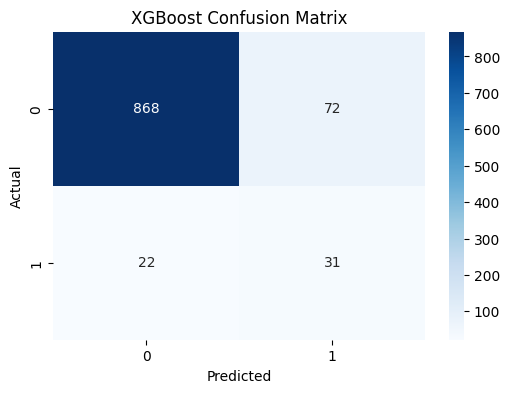

In [6]:
y_pred_xg = model.predict(X_test)

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xg), annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/var/folders/tt/k1lq5c5x7tl4g5pfxq2nx2bw0000gn/T/ipykernel_20753/30874574.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(xgb_metrics.keys()), y=list(xgb_metrics.values()), palette="viridis")


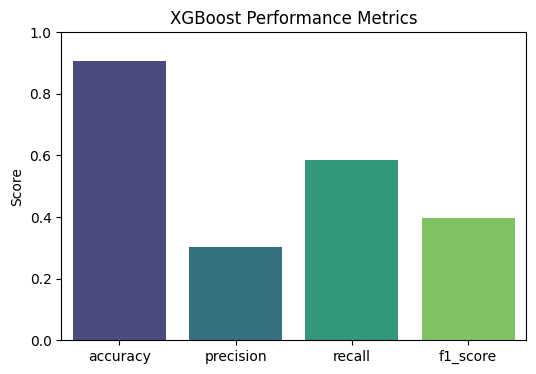

In [7]:
xgb_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_xg),
    "precision": precision_score(y_test, y_pred_xg),
    "recall": recall_score(y_test, y_pred_xg),
    "f1_score": f1_score(y_test, y_pred_xg)}
plt.figure(figsize=(6, 4))
sns.barplot(x=list(xgb_metrics.keys()), y=list(xgb_metrics.values()), palette="viridis")
plt.ylim(0, 1)
plt.title("XGBoost Performance Metrics")
plt.ylabel("Score")
plt.show()

Train Recall: 0.9997341839447103
Test Recall : 0.5849056603773585


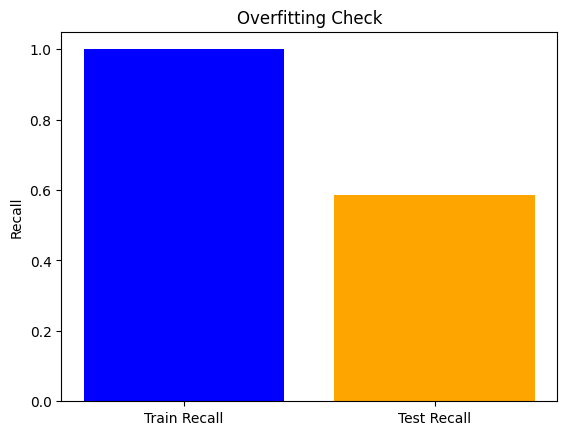

In [8]:
# Add this to check overfitting
train_pred = model.predict(X_resampled)
print("Train Recall:", recall_score(y_resampled, train_pred))
print("Test Recall :", recall_score(y_test, y_pred_xg))
plt.bar(["Train Recall", "Test Recall"], [recall_score(y_resampled, train_pred), recall_score(y_test, y_pred_xg)], color=["blue", "orange"])
plt.ylabel("Recall")
plt.title("Overfitting Check")
plt.show()

In [9]:

rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)

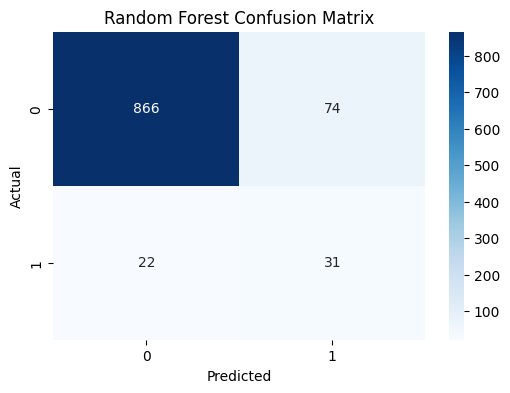

In [10]:
rf.fit(X_resampled, y_resampled)
y_pred_rf = rf.predict(X_test)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


/var/folders/tt/k1lq5c5x7tl4g5pfxq2nx2bw0000gn/T/ipykernel_20753/4027089201.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(rf_metrics.keys()), y=list(rf_metrics.values()), palette="viridis")


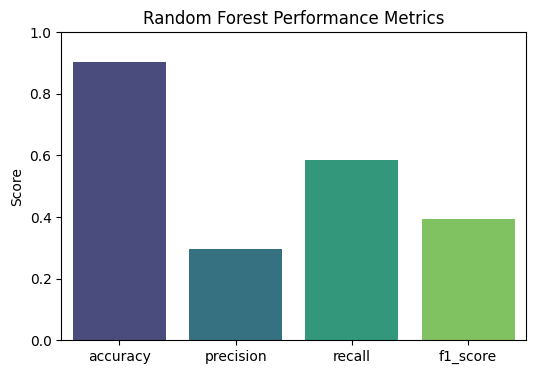

In [11]:
rf_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf),
    "recall": recall_score(y_test, y_pred_rf),
    "f1_score": f1_score(y_test, y_pred_rf)}
plt.figure(figsize=(6, 4))
sns.barplot(x=list(rf_metrics.keys()), y=list(rf_metrics.values()), palette="viridis")
plt.ylim(0, 1)
plt.title("Random Forest Performance Metrics")
plt.ylabel("Score")
plt.show()

Train Recall: 1.0
Test Recall : 0.5849056603773585


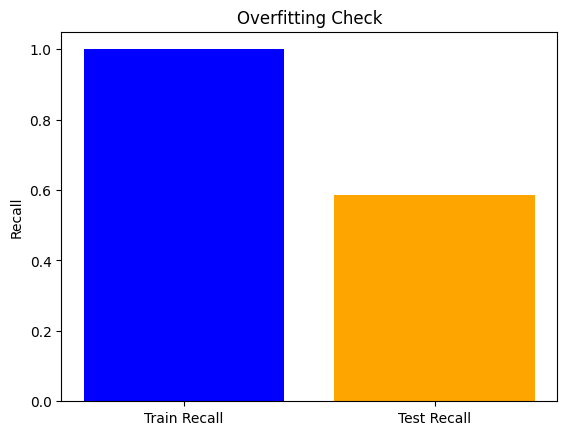

In [12]:
train_pred = rf.predict(X_resampled)
print("Train Recall:", recall_score(y_resampled, train_pred))
print("Test Recall :", recall_score(y_test, y_pred_rf))
plt.bar(["Train Recall", "Test Recall"], [recall_score(y_resampled, train_pred), recall_score(y_test, y_pred_rf)], color=["blue", "orange"])
plt.ylabel("Recall")
plt.title("Overfitting Check")
plt.show()

In [13]:

lgbm = LGBMClassifier(class_weight="balanced", random_state=42)

[LightGBM] [Info] Number of positive: 3762, number of negative: 3762
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 7524, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


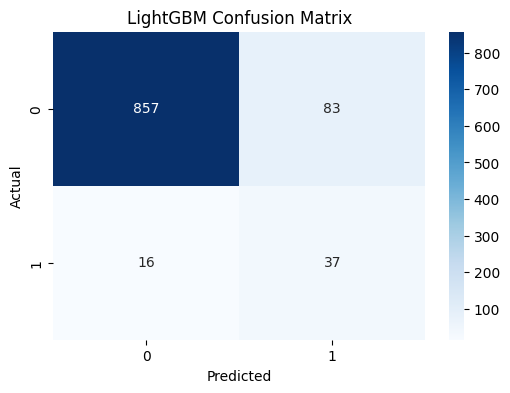

In [14]:
lgbm.fit(X_resampled, y_resampled)
y_pred_lgbm = lgbm.predict(X_test)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lgbm), annot=True, fmt="d", cmap="Blues")
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/var/folders/tt/k1lq5c5x7tl4g5pfxq2nx2bw0000gn/T/ipykernel_20753/1785742543.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(lgbm_metrics.keys()), y=list(lgbm_metrics.values()), palette="viridis")


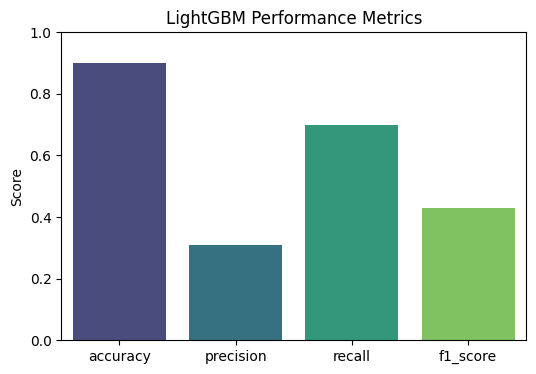

In [15]:
lgbm_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_lgbm),
    "precision": precision_score(y_test, y_pred_lgbm),
    "recall": recall_score(y_test, y_pred_lgbm),
    "f1_score": f1_score(y_test, y_pred_lgbm)}
plt.figure(figsize=(6, 4))
sns.barplot(x=list(lgbm_metrics.keys()), y=list(lgbm_metrics.values()), palette="viridis")
plt.ylim(0, 1)
plt.title("LightGBM Performance Metrics")
plt.ylabel("Score")
plt.show()

Train Recall: 0.9968102073365231
Test Recall : 0.6981132075471698


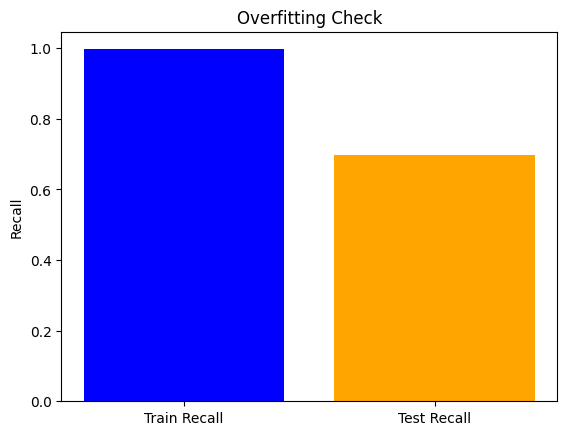

In [16]:
train_pred = lgbm.predict(X_resampled)
print("Train Recall:", recall_score(y_resampled, train_pred))
print("Test Recall :", recall_score(y_test, y_pred_lgbm))
plt.bar(["Train Recall", "Test Recall"], [recall_score(y_resampled, train_pred), recall_score(y_test, y_pred_lgbm)], color=["blue", "orange"])
plt.ylabel("Recall")
plt.title("Overfitting Check")
plt.show()

In [17]:
from sklearn.svm import SVC
svm = SVC(class_weight="balanced", probability=True, random_state=42,kernel="rbf")

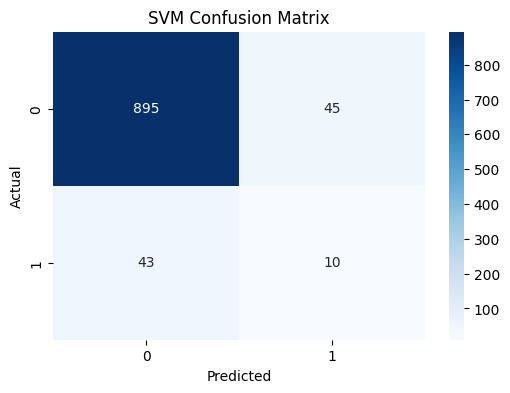

In [18]:
svm.fit(X_resampled, y_resampled)
y_pred_svm = svm.predict(X_test)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt="d", cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/var/folders/tt/k1lq5c5x7tl4g5pfxq2nx2bw0000gn/T/ipykernel_20753/771612594.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(svm_metrics.keys()), y=list(svm_metrics.values()), palette="viridis")


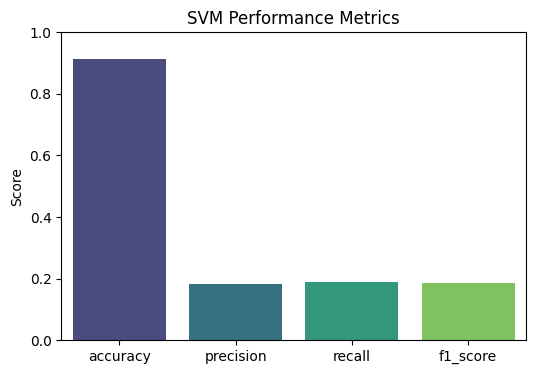

In [22]:
svm_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_svm),
    "precision": precision_score(y_test, y_pred_svm),
    "recall": recall_score(y_test, y_pred_svm),
    "f1_score": f1_score(y_test, y_pred_svm)}
plt.figure(figsize=(6, 4))
sns.barplot(x=list(svm_metrics.keys()), y=list(svm_metrics.values()), palette="viridis")
plt.ylim(0, 1)
plt.title("SVM Performance Metrics")
plt.ylabel("Score")
plt.show()

Train Recall: 0.1796916533758639
Test Recall : 0.18867924528301888


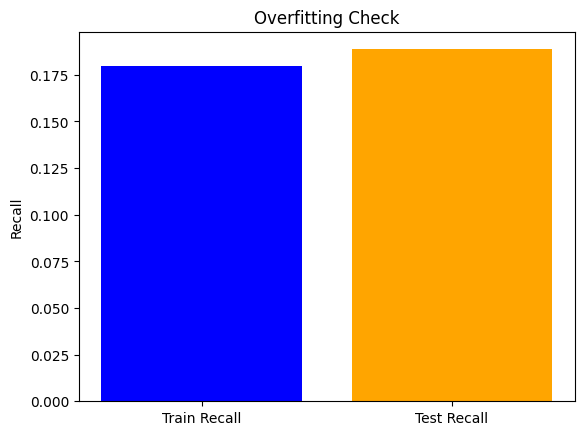

In [19]:
train_pred = svm.predict(X_resampled)
print("Train Recall:", recall_score(y_resampled, train_pred))
print("Test Recall :", recall_score(y_test, y_pred_svm))
plt.bar(["Train Recall", "Test Recall"], [recall_score(y_resampled, train_pred), recall_score(y_test, y_pred_svm)], color=["blue", "orange"])
plt.ylabel("Recall")
plt.title("Overfitting Check")
plt.show()

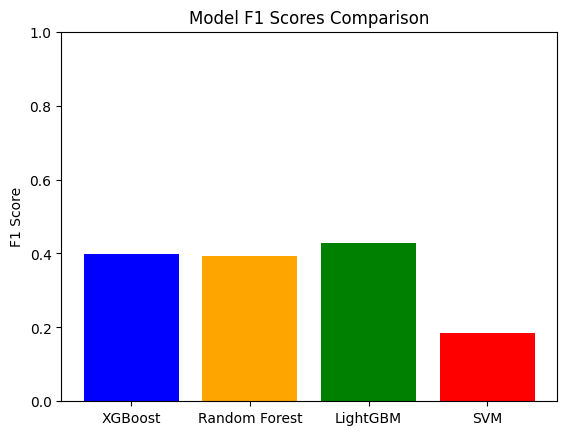

In [21]:
plt.bar(["XGBoost", "Random Forest", "LightGBM", "SVM"],
        [xgb_metrics["f1_score"], rf_metrics["f1_score"], lgbm_metrics["f1_score"], f1_score(y_test, y_pred_svm)],
        color=["blue", "orange", "green", "red"])
plt.ylim(0, 1)
plt.title("Model F1 Scores Comparison")
plt.ylabel("F1 Score")
plt.show()